In [24]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns


In [25]:
from sklearn.linear_model import LogisticRegression

In [26]:
from sklearn import datasets,preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [27]:
pulsar = pd.read_csv('C:\DATA\pulsar_stars.csv')


In [28]:
#taking a look at the size and nulls in te pulsar data ser#
pulsar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17898 entries, 0 to 17897
Data columns (total 9 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0    Mean of the integrated profile                17898 non-null  float64
 1    Standard deviation of the integrated profile  17898 non-null  float64
 2    Excess kurtosis of the integrated profile     17898 non-null  float64
 3    Skewness of the integrated profile            17898 non-null  float64
 4    Mean of the DM-SNR curve                      17898 non-null  float64
 5    Standard deviation of the DM-SNR curve        17898 non-null  float64
 6    Excess kurtosis of the DM-SNR curve           17898 non-null  float64
 7    Skewness of the DM-SNR curve                  17898 non-null  float64
 8   target_class                                   17898 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.2 MB


In [102]:
#taking a look at the first six rows of the data
pulsar.head(6)

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0
5,93.570312,46.698114,0.531905,0.416721,1.636288,14.545074,10.621748,131.394004,0


In [112]:
#making a correlation matrix of the data to see how the features are related# 
pulsar.corr()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
Mean of the integrated profile,1.000000,0.547137,-0.873898,-0.738775,-0.298841,-0.307016,0.234331,0.144033,-0.673181
Standard deviation of the integrated profile,0.547137,1.000000,-0.521435,-0.539793,0.006869,-0.047632,0.029429,0.027691,-0.363708
Excess kurtosis of the integrated profile,-0.873898,-0.521435,1.000000,0.945729,0.414368,0.432880,-0.341209,-0.214491,0.791591
Skewness of the integrated profile,-0.738775,-0.539793,0.945729,1.000000,0.412056,0.415140,-0.328843,-0.204782,0.709528
Mean of the DM-SNR curve,-0.298841,0.006869,0.414368,0.412056,1.000000,0.796555,-0.615971,-0.354269,0.400876
Standard deviation of the DM-SNR curve,-0.307016,-0.047632,0.432880,0.415140,0.796555,1.000000,-0.809786,-0.575800,0.491535
Excess kurtosis of the DM-SNR curve,0.234331,0.029429,-0.341209,-0.328843,-0.615971,-0.809786,1.000000,0.923743,-0.390816
Skewness of the DM-SNR curve,0.144033,0.027691,-0.214491,-0.204782,-0.354269,-0.575800,0.923743,1.000000,-0.259117
target_class,-0.673181,-0.363708,0.791591,0.709528,0.400876,0.491535,-0.390816,-0.259117,1.000000


<Axes: >

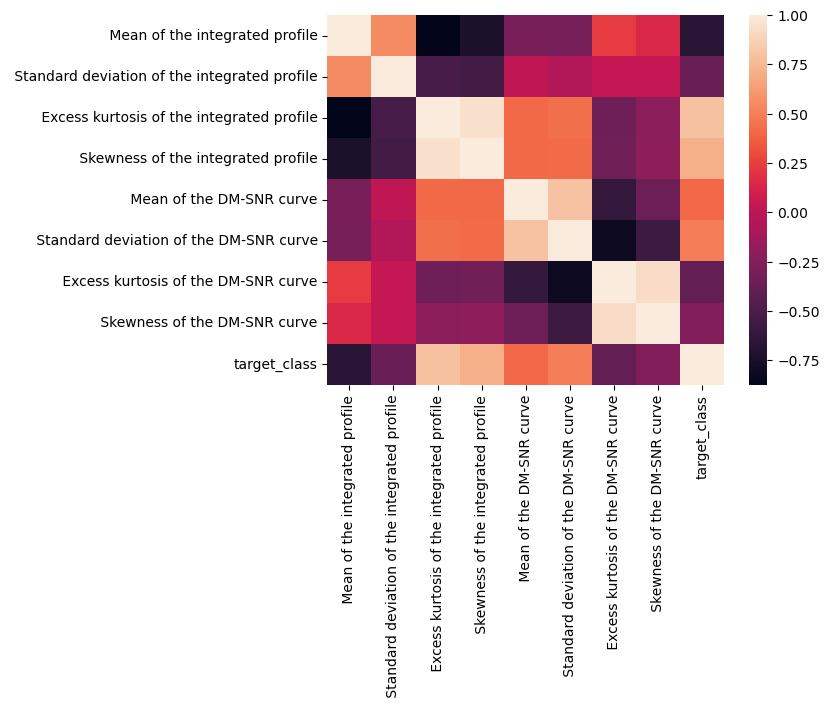

In [113]:
#checking the density of the feature relations with a 
sns.heatmap(pulsar.corr())

Text(0, 0.5, 'Number of pulsar stars')

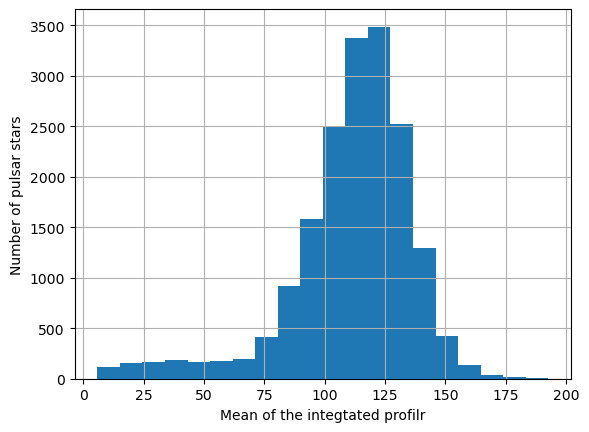

In [49]:
#checking the destributions of the data using boxplot and histogram#
plot1 = pulsar[' Mean of the integrated profile'].hist(bins=20)
plot1.set_xlabel('Mean of the integtated profilr')
plot1.set_ylabel('Number of pulsar stars')

In [51]:
#it can observed from the above plot that the data is skewewd left thus, the SD is lessthan 0 #



In [52]:
#now preparing the Data:
#since our target class is alrady encoded nothing will be dine with again.

In [63]:
#We now standize and slpit the Data into a training and testing sets
from sklearn.model_selection import train_test_split
X,Y= pulsar[:], target
X_train,X_test, Y_train,Y_test = train_test_split(X,Y, test_size=0.5, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(X_train)
x_test = scaler.fit_transform(X_test)


In [65]:
#SVC and metrics#
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [84]:
svc = SVC() #initializing the classifier
svc.fit(X_train, Y_train) # fitting classifier to training sets
Y_pred = svc.predict(X_test)
print('AccuracyScore :' + str(accuracy_score(Y_test,Y_pred))) #compute and print accuracy score

AccuracyScore :0.9725108950720751


In [114]:
#generating evaluation matrix

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print('TrainAccuracy:', accuracy_score(Y_train, model.predict(X_train)))
print('TrainConfusionMatrix:',confusion_matrix(Y_train,model.predict(X_train)))

TrainAccuracy: 0.9727343837300257
TrainConfusionMatrix: [[8102   39]
 [ 205  603]]


In [115]:
print('TestAccuracy:', accuracy_score(Y_test, model.predict(X_test)))
print('TestConfusionMatrix:',confusion_matrix(Y_test,model.predict(X_test)))
print('TestClassificationReport:', classification_report(Y_test,model.predict(X_test)))


TestAccuracy: 0.9725108950720751
TestConfusionMatrix: [[8085   33]
 [ 213  618]]
TestClassificationReport:               precision    recall  f1-score   support

           0       0.97      1.00      0.99      8118
           1       0.95      0.74      0.83       831

    accuracy                           0.97      8949
   macro avg       0.96      0.87      0.91      8949
weighted avg       0.97      0.97      0.97      8949



TypeError: float() argument must be a string or a real number, not 'ABCMeta'

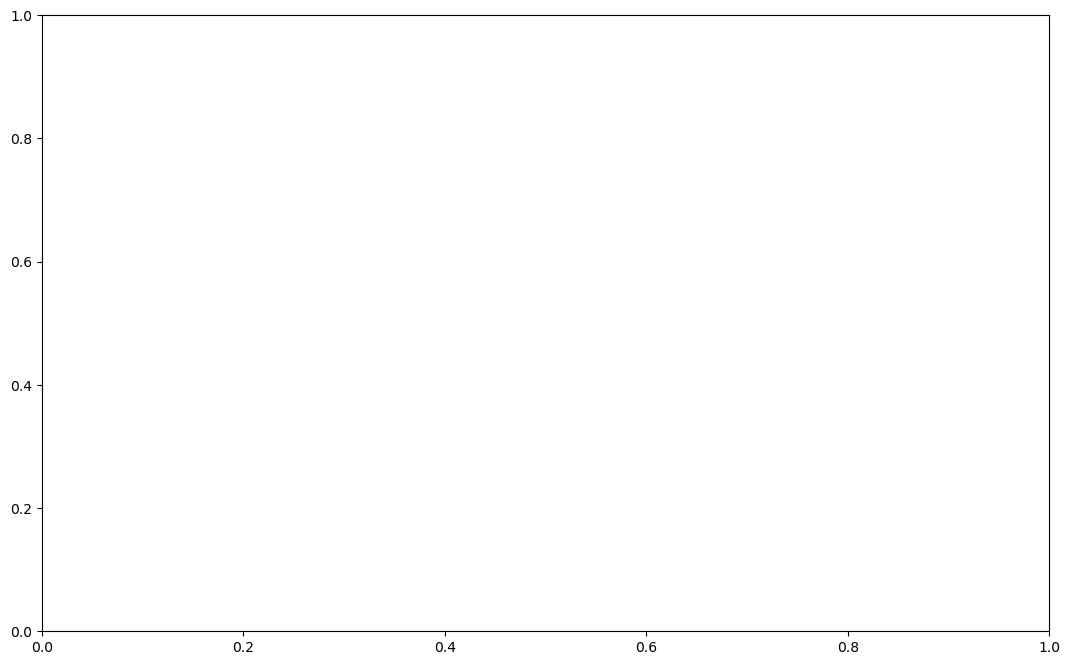

In [131]:
plt.figure(figsize=[13,8])
plt.plot(SVC, accuracy_score(Y_test, model.predict(X_test)), label = 'Testing Accuracy')
plt.plot(SVC,  accuracy_score(Y_train, model.predict(X_train)), label ='Training Accuracy')
plt.legend()
plt.title('-Values VS Accuracy')
plt.xlabel(' ')
plt.ylabel('Accuracy')
plt.xticks(SVC)
plt.show()


